In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:",
      tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
from re import X
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Training images:", x_test.shape)
print("Testing labels:",y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Training images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

#Reshape images for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("Training data shape:", x_train.shape)
print("Training data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Training data shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Create CNN Model
model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolution Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (10 digits)
    Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train[..., None]
x_test = x_test[..., None]

# Create CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.9322 - loss: 0.2263 - val_accuracy: 0.9860 - val_loss: 0.0487
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9895 - val_loss: 0.0368
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9814 - loss: 0.0618 - val_accuracy: 0.9907 - val_loss: 0.0330
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9851 - loss: 0.0480 - val_accuracy: 0.9918 - val_loss: 0.0268
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9877 - loss: 0.0408 - val_accuracy: 0.9920 - val_loss: 0.0324


In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.9909999966621399
Test Accuracy (%): 99.09999966621399


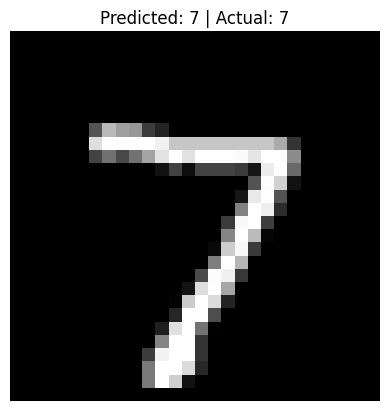

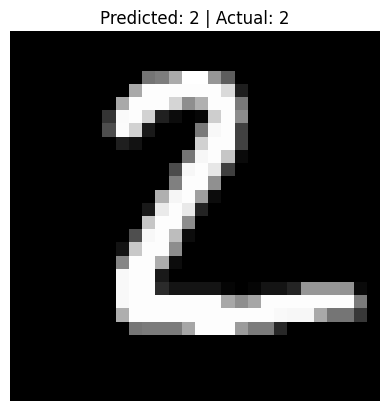

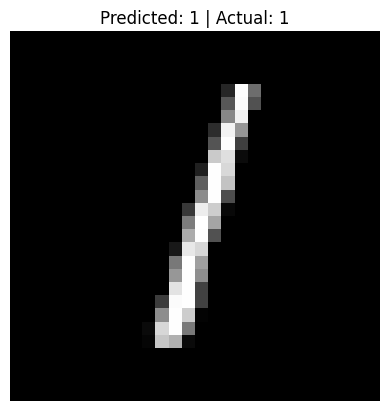

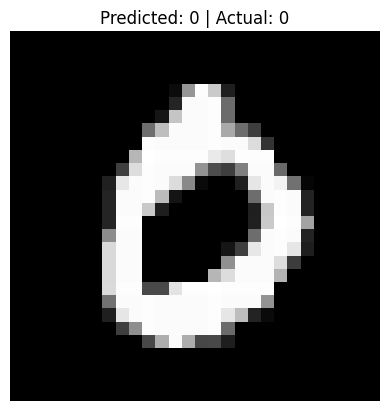

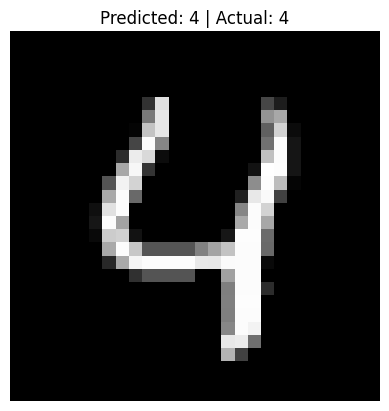

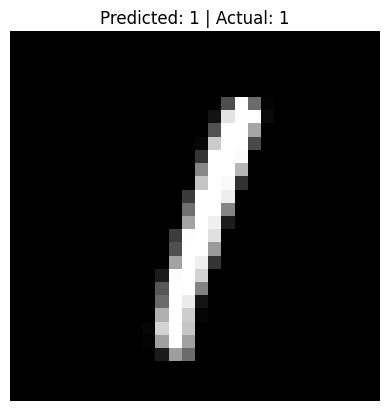

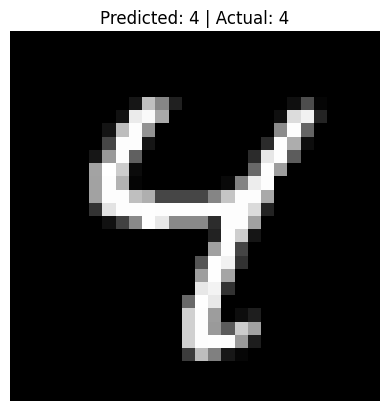

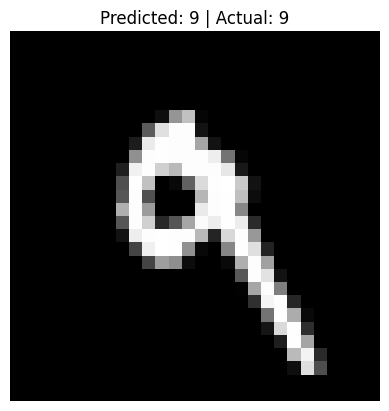

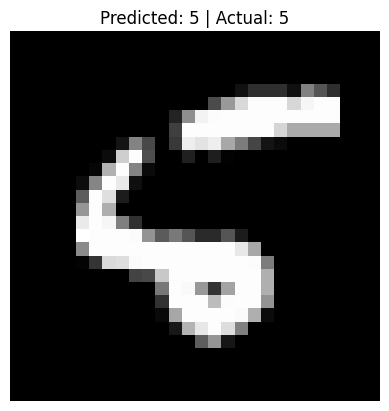

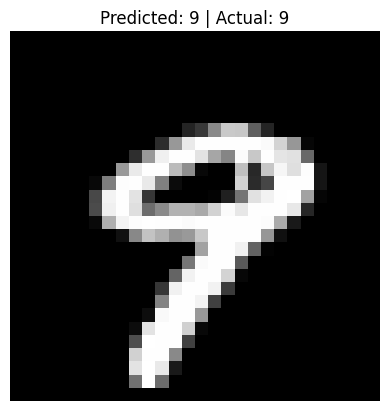

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on test images
predictions = model.predict(x_test[:10], verbose=0)

# Display the first 10 images with predicted labels
for i in range(10):
    predicted_label = np.argmax(predictions[i])

    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Predicted: {predicted_label} | Actual: {y_test[i]}")
    plt.axis("off")
    plt.show()

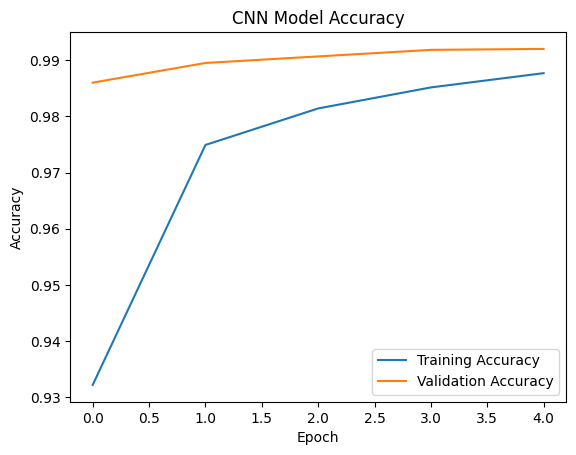

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Model Accuracy')
plt.legend()
plt.show()

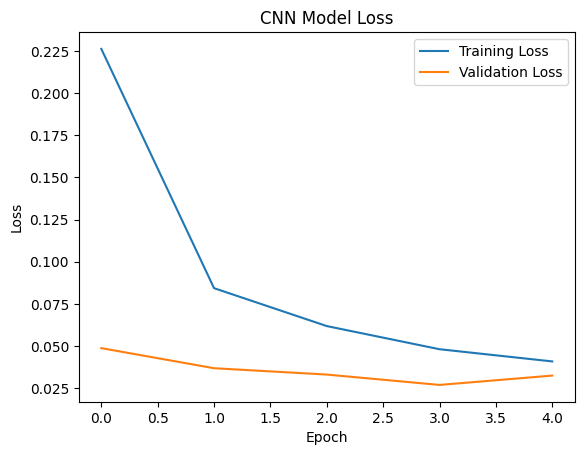

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Model Loss')
plt.legend()
plt.show()

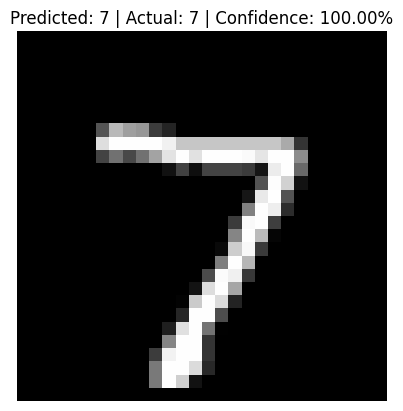

Predicted Digit: 7
Actual Digit: 7
Confidence: 100.00%


In [ ]:
# Show one handwritten digit prediction

import numpy as np
import matplotlib.pyplot as plt

index = 0

image = x_test[index]
prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Predicted: {predicted_digit} | "
    f"Actual: {y_test[index]} | "
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[index])
print("Confidence:", f"{confidence:.2f}%")